In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Wavelength of alignment laser analysis

In [106]:
num_fringes = np.arange(20,220,20) # the number of fringes we counted
dd_C = np.array([3.0, 5.5, 9.0, 11.8, 14.2, 17.1, 19.9, 22.5, 25.0, 28.0])
dd_A = np.array([4.0, 6.3, 9.1, 11.7, 15.0, 17.9, 20.8, 23.8, 25.2, 28.0])
dd_J = np.array([3.5, 6.5, 9.2, 12.0, 14.9, 17.5, 20.1, 23.0, 25.9, 29.3])

In [107]:
df = pd.DataFrame({'N_fringe':num_fringes, 'dd_meas1':dd_C, 'dd_meas2':dd_A, 'dd_meas3':dd_J})
#df.to_csv('align_laser_meas.csv')

In [108]:
data_matrix = np.array((dd_C,dd_A,dd_J))
data_avg = np.mean(data_matrix,axis=0)    # take the average of the three sets of measurements
data_std = np.std(data_matrix,axis=0)     # and the std for weighted fit

sys_err = np.sqrt(3 * 0.5**2)

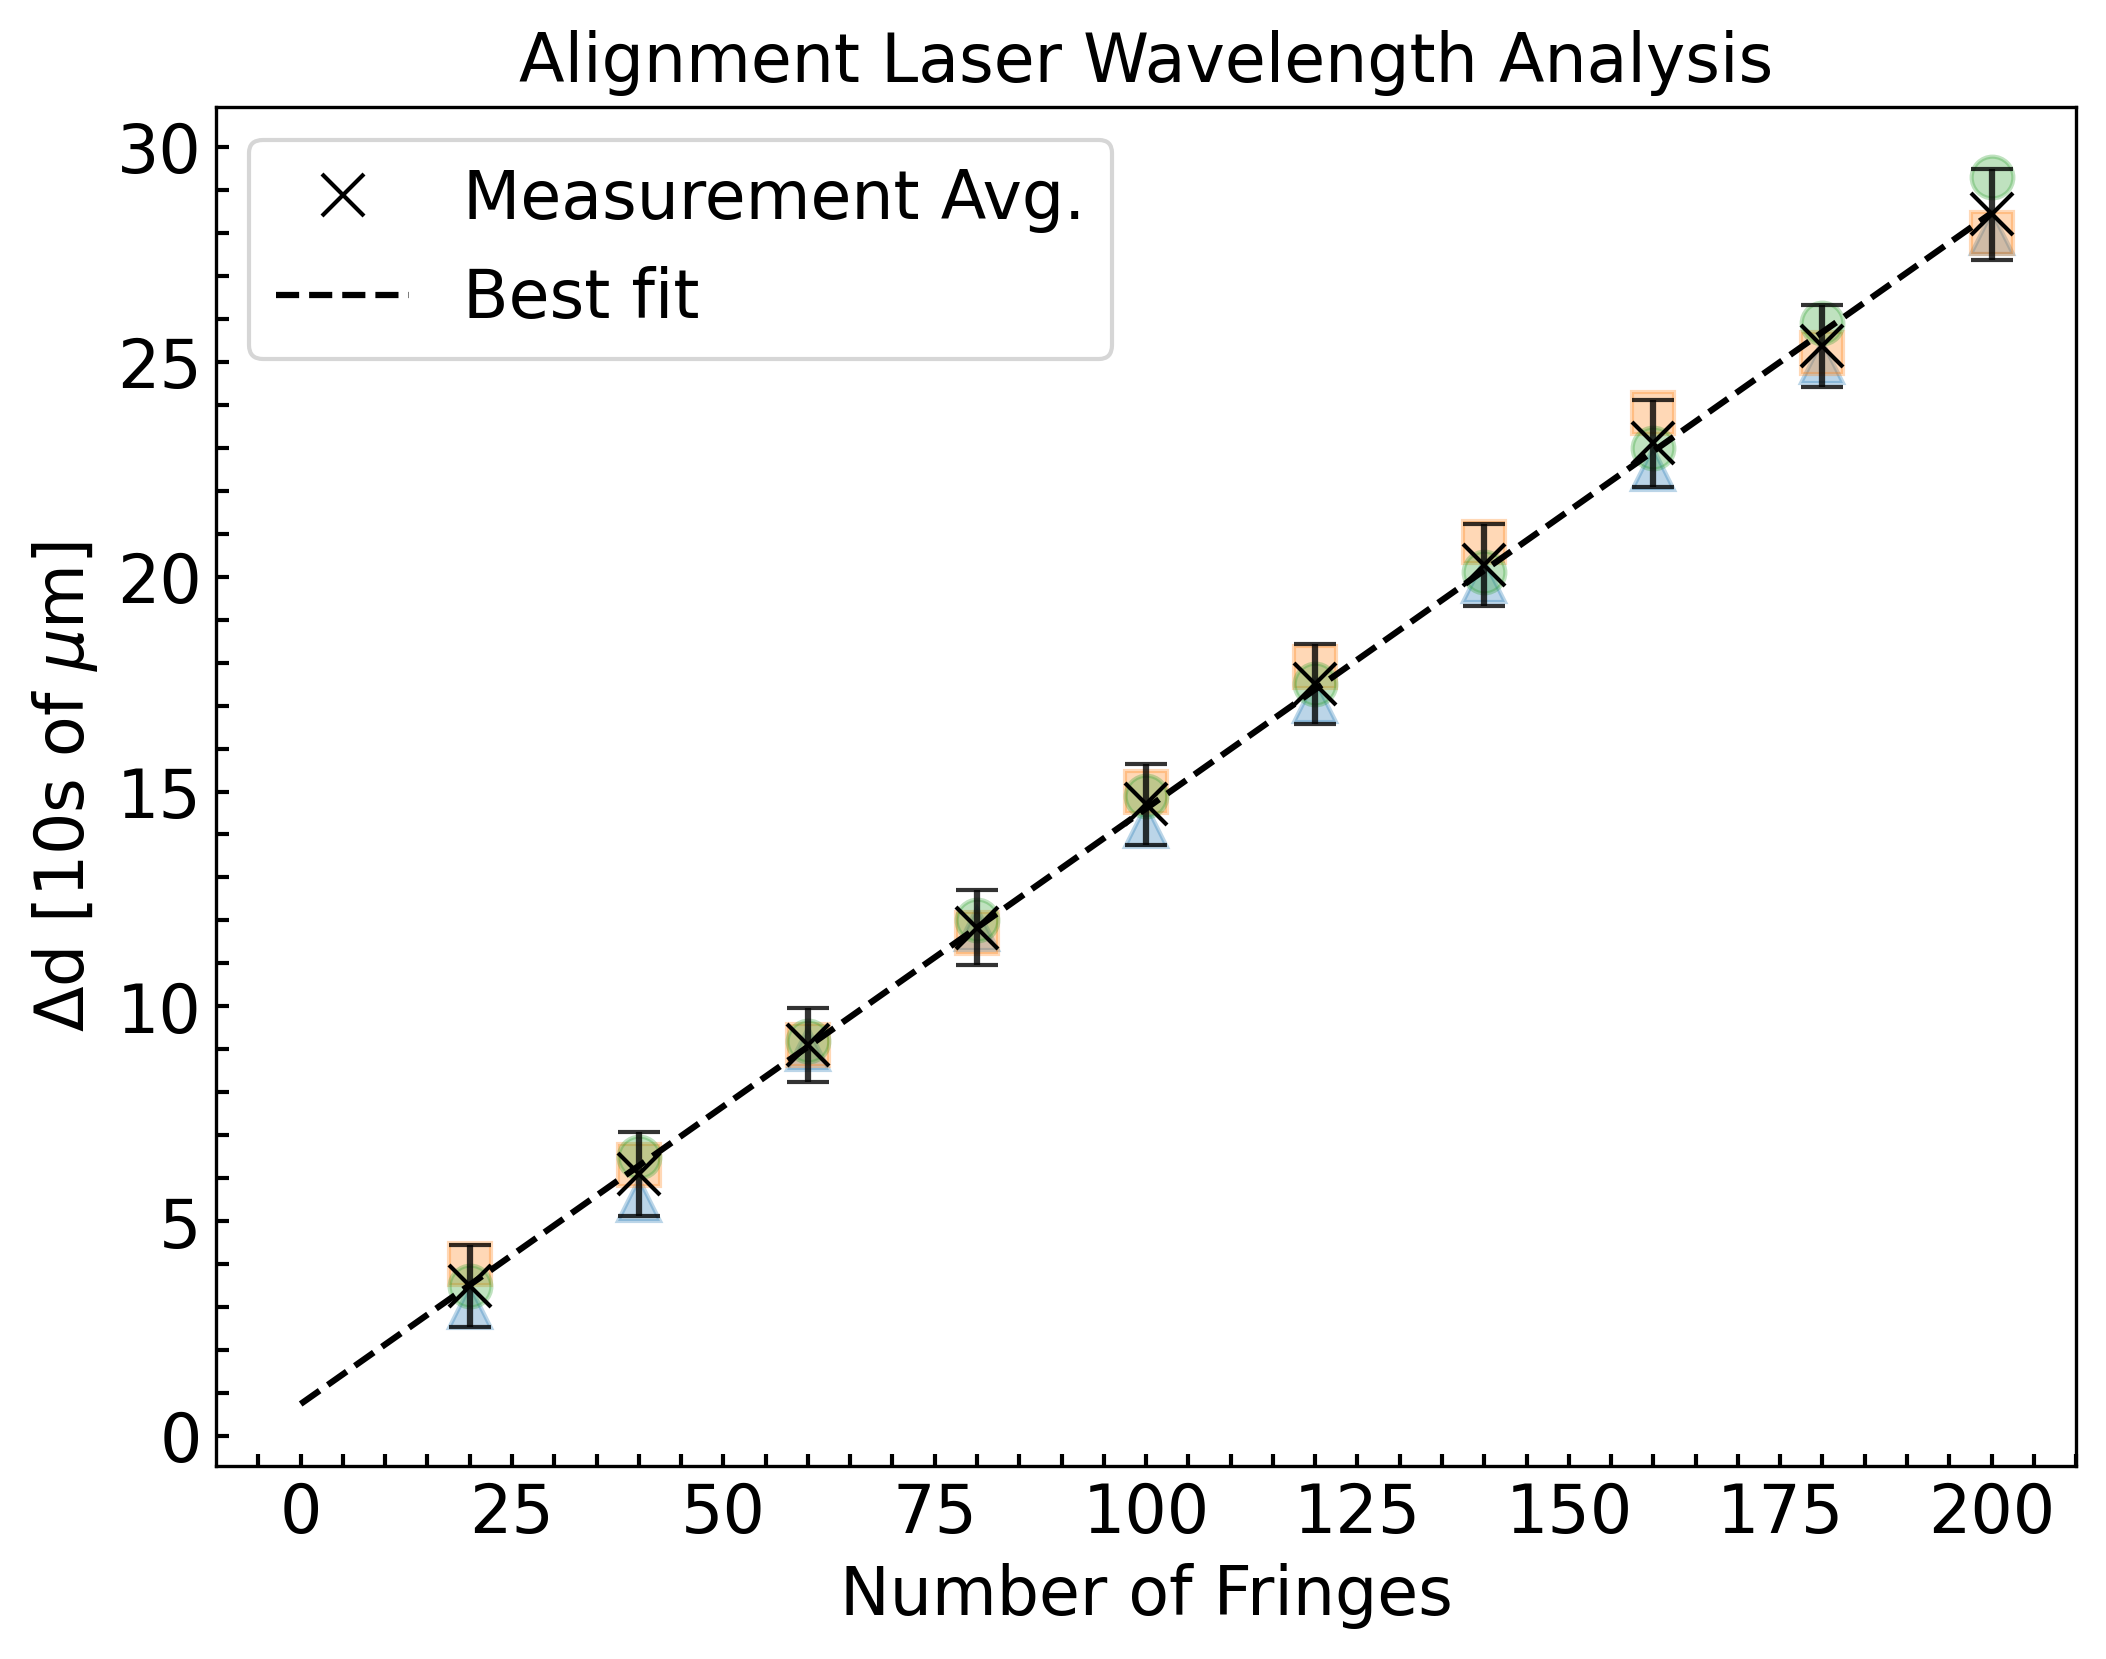

In [109]:
from scipy.optimize import curve_fit 

def f(x,m,b):
    return m * x + b

sigmas = np.sqrt(data_std**2. + sys_err**2.)    # add the systematic and measurement error in quadrate
popt, pcov = curve_fit(f, num_fringes, data_avg, sigma=sigmas)    # do the fit

fig = plt.figure(figsize=(8,6),dpi=300)
fs= 16

# plot the three measurement sets
plt.plot(num_fringes, dd_C, marker='^', markersize=10, ls='none', alpha=0.3)
plt.plot(num_fringes, dd_A, marker='s', markersize=10, ls='none', alpha=0.3)
plt.plot(num_fringes, dd_J, marker='o', markersize=10, ls='none', alpha=0.3)

# plot the avg and error
plt.plot(num_fringes, data_avg, marker='x', markersize=10, color='k', ls='none', label='Measurement Avg.')
plt.errorbar(num_fringes, data_avg, yerr=sigmas, capsize=5, color='k', ls='none', alpha=0.8)

# show the fit
xx = np.arange(0,210,10)
plt.plot(xx, popt[0] * xx + popt[1], c='k', label='Best fit', ls='--')

# style points
plt.xlabel('Number of Fringes', fontsize=fs)
plt.ylabel('$\Delta$d [10s of $\mu$m]', fontsize=fs)
plt.title('Alignment Laser Wavelength Analysis',fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
ax = fig.gca()
ax.minorticks_on()
ax.tick_params(which='both',direction='in', length=3, width=1, color='k')
plt.legend(fontsize=fs)

# plt.savefig('Alignment_analysis.pdf',bbox_inches='tight')

In [110]:
# print best fit parameters and covariance
print(popt, pcov)

[0.13854691 0.7502986 ] [[ 8.42763113e-07 -8.98016945e-05]
 [-8.98016945e-05  1.21868951e-02]]


In [111]:
# calculate the wavelength and its error
wv = popt[0] * 2 * 1e3 * 2
wv_err = np.sqrt(np.diag(pcov))[0]

print('The wavelength is', round(wv,4), '+/-', round(wv_err,4), 'nm')

The wavelength is 554.1876 +/- 0.0009 nm


In [112]:
# calculate the reduced chi2 of the fit
N = len(num_fringes)
Red_Chi2_me = 1.0/(N-2) * np.sum((data_avg - f(num_fringes, popt[0],popt[1]))**2 / sigmas**2)
print('Reduced Chi Squared= ', Red_Chi2_me)

Reduced Chi Squared=  0.029248920560993354
